<a href="https://colab.research.google.com/github/alimoorreza/CS143-SP26-P3/blob/main/p3_informed_search_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing Informed Search Algorithms
## A* Search and Greedy Best-First Search

This notebook also uses a new class in our `mapbots` module called `FullyObservableStreetSweeperWorld` which is a subclass of the StreetSweeperWorld we worked with that reveals more details of the environment that the bot can use to make decisions.

You do need to install a new version of the module. You can do probably do that with something like this (which should upgrade if you ran it on your own computer - or it should always work in Colab).

In [ ]:
import sys

!{sys.executable} -m pip install mapbots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.9 MB/s eta 0:00:00


## Getting Started

We create the bot/environment in the same way, except that the name of the class is `FullyObservableStreetSweeperWorld`

Setting up the map. This may take a few minutes.


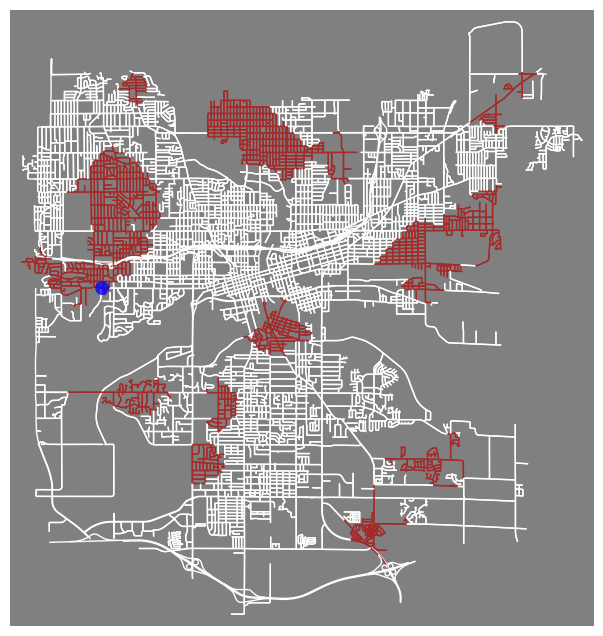

In [ ]:
from mapbots import FullyObservableStreetSweeperWorld

planning_bot = FullyObservableStreetSweeperWorld(place="Des Moines, Iowa, USA",map_number=11)
planning_bot.display_map()

Below is the code for `ucs` search.

## Exercise#1
Implement A* Search. Here are some hints on the things you'll need to do:
* You will need to decide what your path costs will be based on. The easiest option is probably to use the `"length"` value available within each `"street_data"` dictionary. Using `"travel_time"` would be better since the battery is depleted based on travel time.
* You will need to decide on a heuristic. You can use the `"x"` and `"y"` values within each location info dictionary to approximate the straight-line-distance with the Euclidean distance formula (below is some example code for two locations `loc_a` and `loc_b` but it should work with any two). If you are using travel time, you will need to multiply this by something to determine how many seconds you think it should take to follow the straight-line in an admissible way.



In [ ]:
dirty_regions = planning_bot.get_dirty_regions()
dirty_regions

[{'center': 160942958, 'size': 1755},
 {'center': 9678092897, 'size': 954},
 {'center': 160911825, 'size': 1041},
 {'center': 160955006, 'size': 389},
 {'center': 160834040, 'size': 1647},
 {'center': 160929435, 'size': 975},
 {'center': 160976112, 'size': 1258},
 {'center': 160840119, 'size': 193},
 {'center': 160910548, 'size': 622},
 {'center': 160820766, 'size': 186},
 {'center': 160936195, 'size': 1659},
 {'center': 1163836326, 'size': 1300},
 {'center': 160772452, 'size': 1220},
 {'center': 160895527, 'size': 1976},
 {'center': 160911954, 'size': 1340},
 {'center': 4789624236, 'size': 1261},
 {'center': 160995538, 'size': 323},
 {'center': 160971796, 'size': 31},
 {'center': 160934325, 'size': 130},
 {'center': 160790885, 'size': 74},
 {'center': 160842274, 'size': 1802},
 {'center': 160855919, 'size': 1229},
 {'center': 160759140, 'size': 1594},
 {'center': 160914943, 'size': 669},
 {'center': 160908607, 'size': 1211},
 {'center': 160844167, 'size': 1064}]

In [ ]:
loc_a = planning_bot.get_current_location()
loc_a

{'y': 41.5845488,
 'x': -93.6785831,
 'street_count': 3,
 'location_id': 160854122}

In [ ]:
dest4 = dirty_regions[-5]['center']
loc_b = planning_bot.get_location_info( dest4 )
loc_b

{'y': 41.587202, 'x': -93.686872, 'street_count': 3, 'location_id': 160855919}

In [ ]:
import math
straight_line_distance = math.sqrt((loc_a["x"]-loc_b["x"])**2+(loc_a["y"]-loc_b["y"])**2)
straight_line_distance

0.0087031795023388

In [ ]:
# We need a way to represent the nodes in the tree
import math

class SSWSearchNode:

    def __init__(self, location, loc_vector, parent=None):

        self.loc_vector = loc_vector      # this is the x, y coordinates
        self.location   = location        # this is the state

        self.parent = parent  # keeps track of the node that leads to this one
        self.children = []    # a list of all the nodes that appear below this when expanded
        self.g_value = 0
        self.h_value = 0
        self.f_value = 0

    # we'll add all the new nodes using this function when we "expand" this node
    def add_child(self,new_child_node):
        self.children.append(new_child_node)


    # TBD: PLEASE FINISH THE IMPLEMENTATION OF FOLLOWING THREE METHODS
    # TBD: note that g(s) calcualtes the cost of reaching node s from the initial node
    def set_g_value(self, g_value):
      self.g_value = g_value

    # note that h(s) calcualtes the cost of reaching goal node from node s using a function which is easy/efficient to compute
    def set_h_value(self, goal_node):

      self.h_value = -1

    # once you define the other two, calculation of evaluation function f() is straightforward: f() = g() + h()
    # TBD: call this function only after you set the g_value and h_value
    def set_f_value(self):
      self.f_value = -1



In [ ]:
# Solution with PriorityQueue() datastructure from queue module
from queue import PriorityQueue
from collections import deque
from itertools import count
import time


def a_star_search(bot, destination):
    # measure time to find efficiency of ucs()
    start_time        = time.time()

    # initialize the frontier using the initial state of problem
    initial_location  = bot.get_current_location()
    loc_vector        = bot.get_location_info( initial_location["location_id"] )
    root_node         = SSWSearchNode(initial_location["location_id"], loc_vector, None)

    # destination node
    dest_loc_vector   = bot.get_location_info( destination )
    destination_node  = SSWSearchNode(destination, dest_loc_vector, None)


    frontier          = PriorityQueue()
    tie               = count()

    # you need to calculate evaluation function: f(s) = g(s) + h(s) for the root_node
    # TBD: your code here
    # ...
    # ...
    # ...
    frontier.put( (root_node.f_value, next(tie), root_node) )

    # ignoring repeated state
    explored = set()

    total_nodes_expanded = 0

    while True:
        if frontier.empty(): # if the frontier is empty then return failure
            return None    # failure

        # choose a leaf node from the frontier according to strategy
        _, _, chosen_leaf = frontier.get() # REMOVE(frontier): take a thing off of the "PriorityQueue" with minium cost. Removing lowest-cost node in the frointier.
        total_nodes_expanded += 1

        # if the node contains a goal state then return the corresponding solution
        if chosen_leaf.location == destination: # destination is the goal

            # calculate the total time spent during bfs() when the goal is reached
            print('successfully reached goal state in', (time.time() - start_time), 'seconds')

            # we're looping through the tree and creating a list from the locations in each node
            route = deque()
            curr_node = chosen_leaf
            while curr_node.parent != None:
                route.appendleft(curr_node.location)
                curr_node = curr_node.parent
            return route, total_nodes_expanded
        # else expand the node and add the resulting nodes to the frontier
        else:

            explored.add(chosen_leaf.location) # saved it so that you check


            for street in bot.get_outgoing_streets_from_location( chosen_leaf.location ):
                new_node_location = street["end"]["location_id"]
                loc_vector        = bot.get_location_info( new_node_location )
                new_node          = SSWSearchNode(new_node_location, loc_vector, parent=chosen_leaf)



                # you need to calculate evaluation function: f(s) = g(s) + h(s)
                g_value     = chosen_leaf.g_value + street["street_data"]["travel_time"]
                # TBD: your code here
                # ...
                # ...
                # ...


                # you don't need to add a node into the 'frontier' if it has been explored before (saves us memory/time)
                if (new_node.location not in explored):
                  frontier.put( (new_node.f_value, next(tie), new_node) )
                  chosen_leaf.add_child(new_node)

    # calculate the total time spent during bfs() when the goal is reached
    print('Could not reach goal state in', (time.time() - start_time), 'seconds')


Setting up the map. This may take a few minutes.


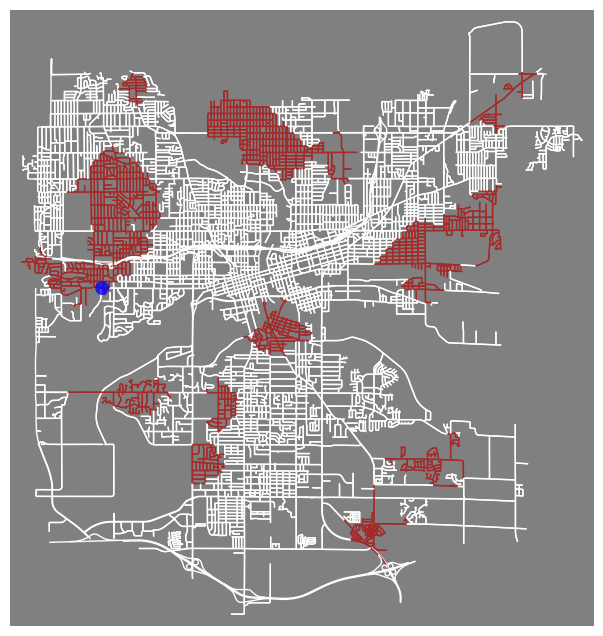

[{'center': 160942958, 'size': 1755},
 {'center': 9678092897, 'size': 954},
 {'center': 160911825, 'size': 1041},
 {'center': 160955006, 'size': 389},
 {'center': 160834040, 'size': 1647},
 {'center': 160929435, 'size': 975},
 {'center': 160976112, 'size': 1258},
 {'center': 160840119, 'size': 193},
 {'center': 160910548, 'size': 622},
 {'center': 160820766, 'size': 186},
 {'center': 160936195, 'size': 1659},
 {'center': 1163836326, 'size': 1300},
 {'center': 160772452, 'size': 1220},
 {'center': 160895527, 'size': 1976},
 {'center': 160911954, 'size': 1340},
 {'center': 4789624236, 'size': 1261},
 {'center': 160995538, 'size': 323},
 {'center': 160971796, 'size': 31},
 {'center': 160934325, 'size': 130},
 {'center': 160790885, 'size': 74},
 {'center': 160842274, 'size': 1802},
 {'center': 160855919, 'size': 1229},
 {'center': 160759140, 'size': 1594},
 {'center': 160914943, 'size': 669},
 {'center': 160908607, 'size': 1211},
 {'center': 160844167, 'size': 1064}]

In [ ]:
# as our mapbot has moved to the destination, you may have to reload the map
from mapbots import FullyObservableStreetSweeperWorld

planning_bot = FullyObservableStreetSweeperWorld(place="Des Moines, Iowa, USA",map_number=11)
planning_bot.display_map()
dirty_regions = planning_bot.get_dirty_regions()
display(dirty_regions)


In [ ]:
dest1 = dirty_regions[-5]['center']
#dest1 = dirty_regions[4]['center']
print('source location:', planning_bot.get_current_location()['location_id'])
print('destination location:', dest1)
calculated_route, total_nodes_expanded = a_star_search(planning_bot, dest1)
print('Number of states (or location_ids) along the solution provided by a_star_search():', len(calculated_route))
print('Number of nodes expanded during a_star_search:', total_nodes_expanded)

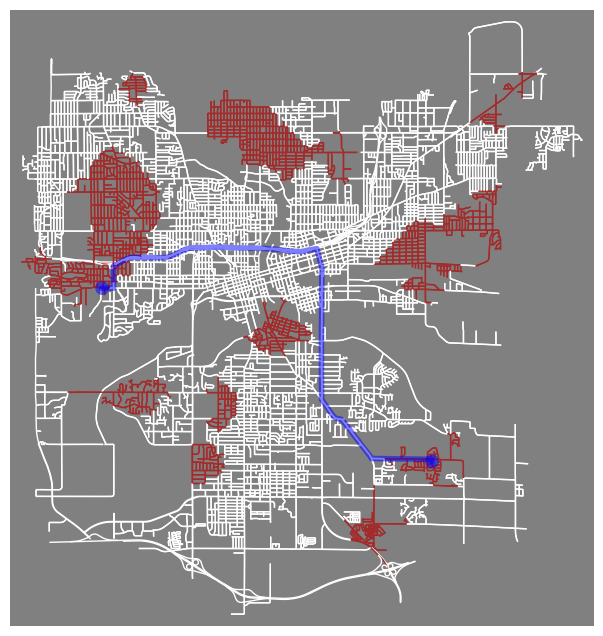

In [ ]:
planning_bot.get_current_location()
for loc in calculated_route:
    planning_bot.move_to(loc)
planning_bot.display_map()

## Exercise#2
Now implement the Greedy Best-First Search. What changes do we need to make to the `a_star_search` code to make it work for `greedy best-first search`?

In [ ]:
# Solution with PriorityQueue() datastructure from queue module
from queue import PriorityQueue
from collections import deque
from itertools import count
import time


def greedy_best_first_search(bot, destination):
    # measure time to find efficiency of ucs()
    start_time        = time.time()

    # initialize the frontier using the initial state of problem
    initial_location  = bot.get_current_location()
    loc_vector        = bot.get_location_info( initial_location["location_id"] )
    root_node         = SSWSearchNode(initial_location["location_id"], loc_vector, None)

    # destination node
    dest_loc_vector   = bot.get_location_info( destination )
    destination_node  = SSWSearchNode(destination, dest_loc_vector, None)


    frontier          = PriorityQueue()
    tie               = count()

    # you need to calculate evaluation function: f(s) = 0 + h(s)
    # TBD: your code here
    # ...
    # ...
    # ...
    frontier.put( (root_node.f_value, next(tie), root_node) )

    # ignoring repeated state
    explored = set()

    total_nodes_expanded = 0

    while True:
        if frontier.empty(): # if the frontier is empty then return failure
            return None    # failure

        # choose a leaf node from the frontier according to strategy
        _, _, chosen_leaf = frontier.get() # REMOVE(frontier): take a thing off of the "PriorityQueue" with minium cost. Removing lowest-cost node in the frointier.
        total_nodes_expanded += 1


        # if the node contains a goal state then return the corresponding solution
        if chosen_leaf.location == destination: # destination is the goal

            # calculate the total time spent during bfs() when the goal is reached
            print('successfully reached goal state in', (time.time() - start_time), 'seconds')

            # we're looping through the tree and creating a list from the locations in each node
            route = deque()
            curr_node = chosen_leaf
            while curr_node.parent != None:
                route.appendleft(curr_node.location)
                curr_node = curr_node.parent
            return route, total_nodes_expanded
        # else expand the node and add the resulting nodes to the frontier
        else:

            explored.add(chosen_leaf.location) # saved it so that you check

            for street in bot.get_outgoing_streets_from_location( chosen_leaf.location ):
                new_node_location = street["end"]["location_id"]
                loc_vector        = bot.get_location_info( new_node_location )
                new_node          = SSWSearchNode(new_node_location, loc_vector, parent=chosen_leaf)



                # you need to calculate evaluation function: f(s) = 0 + h(s)
                # TBD: your code here
                # ...
                # ...
                # ...



                # you don't need to add a node into the 'frontier' if it has been explored before (saves us memory/time)
                if (new_node.location not in explored): # and (new_node.location not in frontier_nodes):
                  frontier.put( (new_node.f_value, next(tie), new_node) )
                  chosen_leaf.add_child(new_node)

    # calculate the total time spent during bfs() when the goal is reached
    print('Could not reach goal state in', (time.time() - start_time), 'seconds')


In [ ]:
streets = planning_bot.get_outgoing_streets_from_location( planning_bot.get_current_location()['location_id'] )
#streets[0]
streets[0]['street_data']['travel_time']

7.00848346829808

Setting up the map. This may take a few minutes.


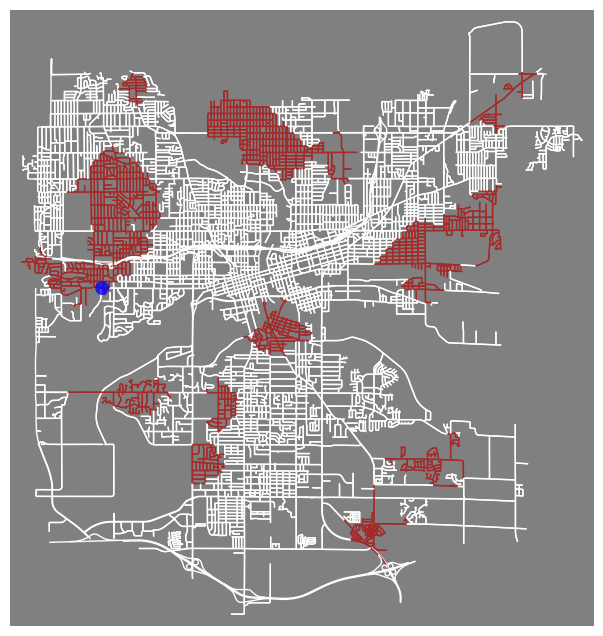

[{'center': 160942958, 'size': 1755},
 {'center': 9678092897, 'size': 954},
 {'center': 160911825, 'size': 1041},
 {'center': 160955006, 'size': 389},
 {'center': 160834040, 'size': 1647},
 {'center': 160929435, 'size': 975},
 {'center': 160976112, 'size': 1258},
 {'center': 160840119, 'size': 193},
 {'center': 160910548, 'size': 622},
 {'center': 160820766, 'size': 186},
 {'center': 160936195, 'size': 1659},
 {'center': 1163836326, 'size': 1300},
 {'center': 160772452, 'size': 1220},
 {'center': 160895527, 'size': 1976},
 {'center': 160911954, 'size': 1340},
 {'center': 4789624236, 'size': 1261},
 {'center': 160995538, 'size': 323},
 {'center': 160971796, 'size': 31},
 {'center': 160934325, 'size': 130},
 {'center': 160790885, 'size': 74},
 {'center': 160842274, 'size': 1802},
 {'center': 160855919, 'size': 1229},
 {'center': 160759140, 'size': 1594},
 {'center': 160914943, 'size': 669},
 {'center': 160908607, 'size': 1211},
 {'center': 160844167, 'size': 1064}]

In [ ]:
# as our mapbot has moved to the destination, you may have to reload the map
from mapbots import FullyObservableStreetSweeperWorld

planning_bot = FullyObservableStreetSweeperWorld(place="Des Moines, Iowa, USA",map_number=11)
planning_bot.display_map()
dirty_regions = planning_bot.get_dirty_regions()
display(dirty_regions)

In [ ]:
dest1 = dirty_regions[-5]['center']
#dest1 = dirty_regions[4]['center']
print('source location:', planning_bot.get_current_location()['location_id'])
print('destination location:', dest1)
calculated_route, total_nodes_expanded = greedy_best_first_search(planning_bot,dest1)
print('Number of states (or location_ids) along the solution provided by greedy_best_first_search():', len(calculated_route))
print('Number of nodes expanded during greedy_best_first_search:', total_nodes_expanded)

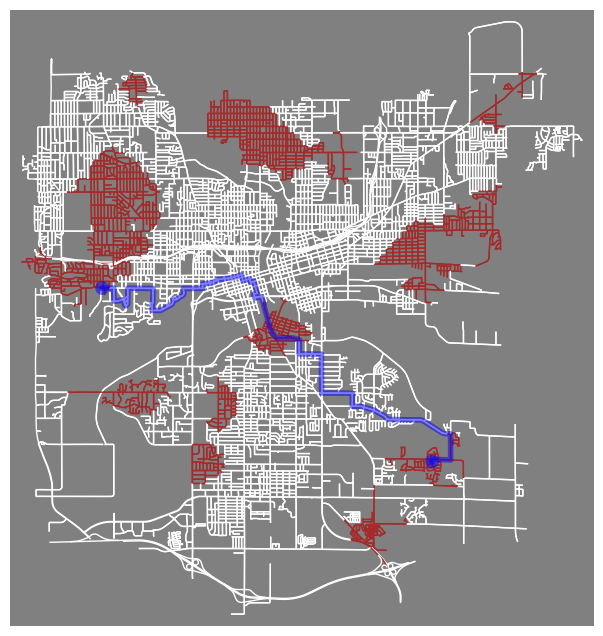

In [ ]:
planning_bot.get_current_location()
for loc in calculated_route:
    planning_bot.move_to(loc)
planning_bot.display_map()

Complete and run both A* Search and Greedy Best-First Search on two copies of the same map, and then display the routes to see the different routes that were found (they may be similar depending on the map and locations). Make sure the displayed maps are visible in the notebook you submit.

> You should complete the exercises and then perform a comparative analysis using the table below. First, use the source location with `location_id` **160854122** and the goal location with `location_id` **160855919**. This table should help you organize and compare your results for the given destination node in the Des Moines map.



| **Informed search method**     | **Number of nodes along the path**| **Number of nodes expanded**  | **Time took** |
|---------------|--------------------|----------------|----------------|
| greedy\_best\_first           |                    |                   |                |
| a_star         |                    |                |                   |


> You should redo a similar comparative analysis using the table below. This time, keep the source location as `location_id` **160854122**, but choose a different goal location (e.g., `location_id` **160834040**). Then, organize and report your results for that goal node in the Des Moines map.


| **Informed search method**     | **Number of nodes along the path**| **Number of nodes expanded**  | **Time took** |
|---------------|--------------------|----------------|----------------|
| greedy\_best\_first           |                    |                   |                |
| a_star         |                    |                |                   |


Also include a text/Markdown cell that addresses the following points:

1. Explain the basis on which the path costs are computed.

2. Specify the heuristic function used.

3. Provide a brief description of the modifications made to the code.

4. Discuss any differences observed—using the comparative table above—in the computed routes, execution time, number of nodes expanded, and related metrics.

5. Conclude by stating which algorithm you recommend, A* Search or Greedy Best-First Search, and justify your choice briefly.

### Grading

The assignment is worth 10 points. Partial credit (4–6 points) will be awarded if any of the required components are incomplete.

* Up to 2 points: You made code changes that demonstrate a reasonable attempt to complete the implementation of the **SSWSearchNode** class—specifically, by implementing the heuristic function `set_h_value(), set_g_value()`, and `set_f_value()`.

* Up to 4 points: You made code changes that demonstrate a reasonable attempt toward implementing A* search.

* Up to 5 points: You attempted an A* implementation that does not fully work, but you clearly describe the issues encountered and provide your best assessment of how they might be resolved.

* Up to 7 points: You implemented a working version of A* search and attempted a Greedy Best-First Search implementation that does not fully work, but you clearly describe the issues encountered and provide your best assessment of how they might be resolved.

* Up to 8 points: You implemented working versions of both A* search and Greedy Best-First Search and successfully display the maps with the computed routes.

* Up to 10 points: You implemented a working version of A* search, compared its results with your Greedy Best-First Search implementation, and addressed all of the required items in a text/Markdown cell.

### Turning it in

Share the notebook in the same way you did for Project 2.
